<a href="https://colab.research.google.com/github/logiha/northstar-database-analytics/blob/main/NorthStar_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

base_url = "https://raw.githubusercontent.com/logiha/northstar-database-analytics/main/"

customers = pd.read_csv(base_url + "customers.csv")
orders = pd.read_csv(base_url + "orders.csv")
deliveries = pd.read_csv(base_url + "deliveries.csv")
complaints = pd.read_csv(base_url + "complaints.csv")
vehicles = pd.read_csv(base_url + "vehicles.csv")
incidents = pd.read_csv(base_url + "incidents.csv")
drivers = pd.read_csv(base_url + "drivers.csv")
hubs = pd.read_csv(base_url + "hubs.csv")
app_events = pd.read_csv(base_url + "app_events.csv")

print(deliveries.shape)
print(orders.shape)
print(customers.shape)

(950, 13)
(1250, 11)
(650, 9)


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
customers = pd.read_csv("customers.csv")
orders = pd.read_csv("orders.csv")
deliveries = pd.read_csv("deliveries.csv")
complaints = pd.read_csv("complaints.csv")
vehicles = pd.read_csv("vehicles.csv")
incidents = pd.read_csv("incidents.csv")
drivers = pd.read_csv("drivers.csv")
hubs = pd.read_csv("hubs.csv")
app_events = pd.read_csv("app_events (2).csv")

In [ ]:
customers.head()

,customer_id,age,home_zone,customer_type,signup_date,loyalty_score,app_engagement_score,preferred_channel,account_status
0,C0001,26,North,SME,2024-11-27 04:25:00,44.9,69.2,App,Active
1,C0002,61,AIRPORT,Consumer,2025-10-28 01:04:00,55.4,66.6,App,Active
2,C0003,66,East,Consumer,2025-07-02 03:23:00,75.9,33.8,NaN,Active
3,C0004,75,CENTRAL,Consumer,2025-08-19 01:58:00,32.5,33.0,App,Active
4,C0005,26,Riverside,Consumer,2025-06-03 06:02:00,55.9,100.0,Web,Active


In [ ]:
deliveries.head()


,delivery_id,order_id,driver_id,vehicle_id,hub_id,dispatch_time,delivery_completed_at,delivery_status,route_distance_km,manual_route_override_count,proof_of_completion_missing,customer_rating_post_delivery,fuel_or_charge_cost
0,DL00001,O00938,D004,V056,H05,2024-06-18 10:57:00,2024-06-19 09:05:59.904311,Failed,17.26,1,0,3.07,12.05
1,DL00002,O00004,D138,V007,H02,2025-01-11 18:45:00,2025-01-11 17:39:00.000000,OnTime,10.34,1,0,5.00,13.41
2,DL00003,O00639,D006,V049,H02,2025-06-02 20:39:00,2025-06-02 21:45:32.366770,OnTime,7.92,0,0,4.98,8.51
3,DL00004,O00313,D116,V055,H02,2024-03-08 23:31:00,2024-03-09 23:30:08.103702,Delayed,16.42,0,0,4.18,13.62
4,DL00005,O00844,D108,V034,H01,2025-09-21 11:43:00,2025-09-21 15:45:34.131056,OnTime,14.52,1,0,4.18,9.22


In [ ]:
complaints.head()

,complaint_id,customer_id,order_id,complaint_type,channel,severity,created_at,status,resolution_days,compensation_amount
0,CP0001,C0464,O00814,AppIssue,App,High,2025-03-30 02:36:00,Open,11,23.99
1,CP0002,C0056,O00628,MissedPickup,Phone,Medium,2024-11-07 10:05:00,Open,4,21.64
2,CP0003,C0469,O00384,Delay,Chatbot,High,2024-01-02 15:47:00,Open,16,26.41
3,CP0004,C0631,O00406,Delay,App,Medium,2025-01-14 13:07:00,AwaitingCustomer,7,23.44
4,CP0005,C0535,O00154,Delay,Email,Medium,2024-08-31 05:56:00,Resolved,1,16.18


In [ ]:
complaints['complaint_type'].value_counts()

,count
complaint_type,
Delay,101
MissedPickup,64
AppIssue,53
DriverBehaviour,51
SupportExperience,20
Billing,16
Damage,15


The complaint analysis showed the most common problems faced by customers in NorthStar services. A large number of complaints related to delays and service issues indicates that there may be inefficiencies in the delivery operations and route management system.


In [ ]:
deliveries['delivery_status'].value_counts()

,count
delivery_status,
OnTime,616
Delayed,202
Failed,132


In [ ]:
deliveries.groupby(
'delivery_status'
)['manual_route_override_count'].mean()

,manual_route_override_count
delivery_status,
Delayed,1.074257
Failed,1.037879
OnTime,0.920455


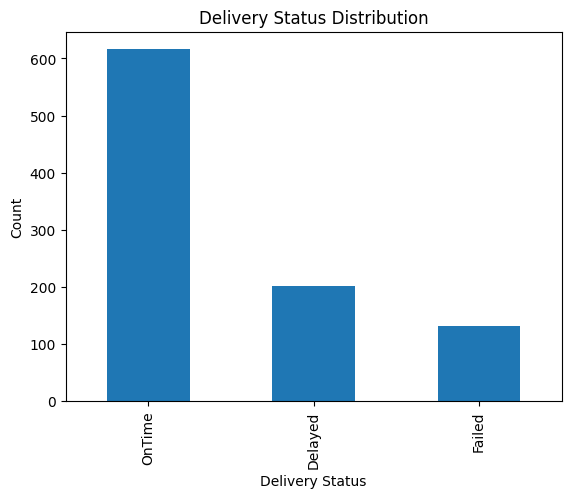

In [ ]:
deliveries['delivery_status'].value_counts().plot(kind='bar')

plt.title('Delivery Status Distribution')

plt.xlabel('Delivery Status')

plt.ylabel('Count')

plt.show()

The delivery status analysis shows that most of the deliveries were completed on time. However, there were still many delayed and failed deliveries, which suggests there are some inefficiencies in NorthStar’s logistics and route management operations. These delivery issues could reduce customer satisfaction and affect the overall performance of the company.


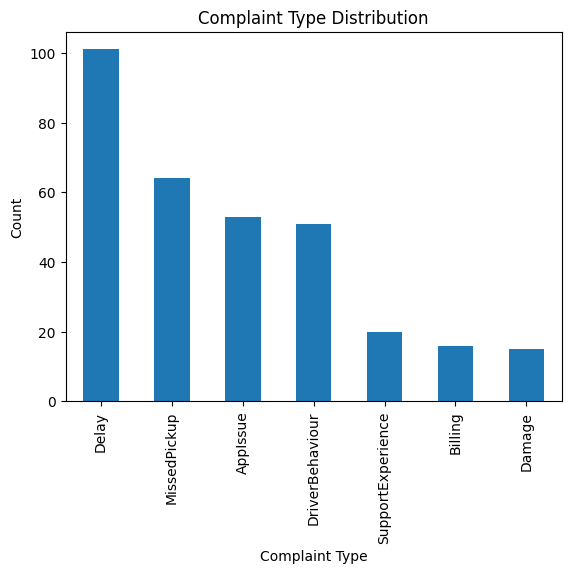

In [ ]:
complaints['complaint_type'].value_counts().plot(kind='bar')

plt.title('Complaint Type Distribution')

plt.xlabel('Complaint Type')

plt.ylabel('Count')

plt.show()

In [ ]:
vehicles['maintenance_status'].value_counts()


,count
maintenance_status,
Active,67
InRepair,36
Scheduled,17


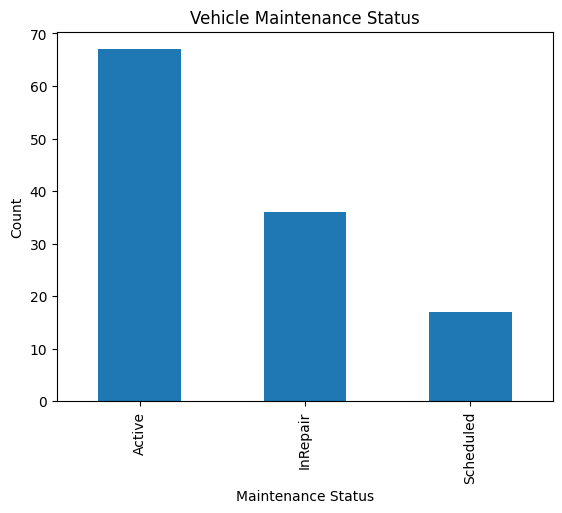

In [ ]:
vehicles['maintenance_status'].value_counts().plot(kind='bar')

plt.title('Vehicle Maintenance Status')

plt.xlabel('Maintenance Status')

plt.ylabel('Count')

plt.show()

In [ ]:
hubs.head()


,hub_id,hub_name,zone,hub_type,capacity_score
0,H01,North Exchange,North,Dispatch,82
1,H02,South Link,South,Dispatch,78
2,H03,East Dock,East,Warehouse,74
3,H04,West Gate,West,Dispatch,69
4,H05,Central Core,Central,Control,88


In [ ]:
hubs['zone'].value_counts()


,count
zone,
Central,2
South,1
North,1
East,1
West,1
Airport,1
Riverside,1


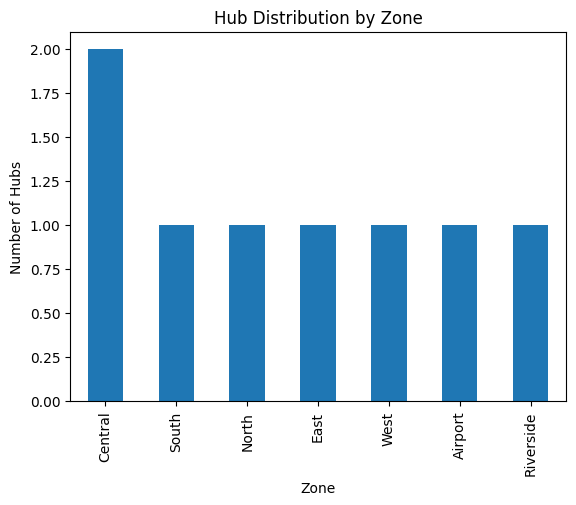

In [ ]:
hubs['zone'].value_counts().plot(kind='bar')

plt.title('Hub Distribution by Zone')

plt.xlabel('Zone')

plt.ylabel('Number of Hubs')

plt.show()

The hub analysis showed differences in how operational hubs are distributed across different zones. An uneven distribution of hubs may cause service inefficiencies, delivery delays and inconsistent delivery performance within NorthStar’s operational network.


In [ ]:
delivery_hub = deliveries.merge(
hubs,
on='hub_id'
)

delivery_hub.head()

,delivery_id,order_id,driver_id,vehicle_id,hub_id,dispatch_time,delivery_completed_at,delivery_status,route_distance_km,manual_route_override_count,proof_of_completion_missing,customer_rating_post_delivery,fuel_or_charge_cost,hub_name,zone,hub_type,capacity_score
0,DL00001,O00938,D004,V056,H05,2024-06-18 10:57:00,2024-06-19 09:05:59.904311,Failed,17.26,1,0,3.07,12.05,Central Core,Central,Control,88
1,DL00002,O00004,D138,V007,H02,2025-01-11 18:45:00,2025-01-11 17:39:00.000000,OnTime,10.34,1,0,5.00,13.41,South Link,South,Dispatch,78
2,DL00003,O00639,D006,V049,H02,2025-06-02 20:39:00,2025-06-02 21:45:32.366770,OnTime,7.92,0,0,4.98,8.51,South Link,South,Dispatch,78
3,DL00004,O00313,D116,V055,H02,2024-03-08 23:31:00,2024-03-09 23:30:08.103702,Delayed,16.42,0,0,4.18,13.62,South Link,South,Dispatch,78
4,DL00005,O00844,D108,V034,H01,2025-09-21 11:43:00,2025-09-21 15:45:34.131056,OnTime,14.52,1,0,4.18,9.22,North Exchange,North,Dispatch,82


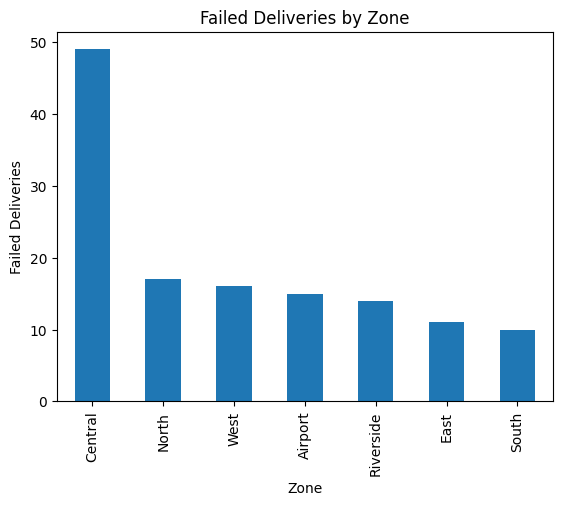

In [ ]:
failed_deliveries[
'zone'
].value_counts().plot(kind='bar')

plt.title('Failed Deliveries by Zone')

plt.xlabel('Zone')

plt.ylabel('Failed Deliveries')

plt.show()

In [ ]:
import os
os.listdir('/content')

['.config', 'sample_data']

In [ ]:
import pandas as pd

deliveries = pd.read_csv('/content/deliveries.csv')
hubs = pd.read_csv('/content/hubs.csv')
complaints = pd.read_csv('/content/complaints.csv')

deliveries.head()

,delivery_id,order_id,driver_id,vehicle_id,hub_id,dispatch_time,delivery_completed_at,delivery_status,route_distance_km,manual_route_override_count,proof_of_completion_missing,customer_rating_post_delivery,fuel_or_charge_cost
0,DL00001,O00938,D004,V056,H05,2024-06-18 10:57:00,2024-06-19 09:05:59.904311,Failed,17.26,1,0,3.07,12.05
1,DL00002,O00004,D138,V007,H02,2025-01-11 18:45:00,2025-01-11 17:39:00.000000,OnTime,10.34,1,0,5.00,13.41
2,DL00003,O00639,D006,V049,H02,2025-06-02 20:39:00,2025-06-02 21:45:32.366770,OnTime,7.92,0,0,4.98,8.51
3,DL00004,O00313,D116,V055,H02,2024-03-08 23:31:00,2024-03-09 23:30:08.103702,Delayed,16.42,0,0,4.18,13.62
4,DL00005,O00844,D108,V034,H01,2025-09-21 11:43:00,2025-09-21 15:45:34.131056,OnTime,14.52,1,0,4.18,9.22


In [ ]:
delivery_hub = deliveries.merge(
    hubs,
    on='hub_id',
    how='left'
)

delivery_hub.head()

,delivery_id,order_id,driver_id,vehicle_id,hub_id,dispatch_time,delivery_completed_at,delivery_status,route_distance_km,manual_route_override_count,proof_of_completion_missing,customer_rating_post_delivery,fuel_or_charge_cost,hub_name,zone,hub_type,capacity_score
0,DL00001,O00938,D004,V056,H05,2024-06-18 10:57:00,2024-06-19 09:05:59.904311,Failed,17.26,1,0,3.07,12.05,Central Core,Central,Control,88
1,DL00002,O00004,D138,V007,H02,2025-01-11 18:45:00,2025-01-11 17:39:00.000000,OnTime,10.34,1,0,5.00,13.41,South Link,South,Dispatch,78
2,DL00003,O00639,D006,V049,H02,2025-06-02 20:39:00,2025-06-02 21:45:32.366770,OnTime,7.92,0,0,4.98,8.51,South Link,South,Dispatch,78
3,DL00004,O00313,D116,V055,H02,2024-03-08 23:31:00,2024-03-09 23:30:08.103702,Delayed,16.42,0,0,4.18,13.62,South Link,South,Dispatch,78
4,DL00005,O00844,D108,V034,H01,2025-09-21 11:43:00,2025-09-21 15:45:34.131056,OnTime,14.52,1,0,4.18,9.22,North Exchange,North,Dispatch,82


In [9]:
import matplotlib.pyplot as plt

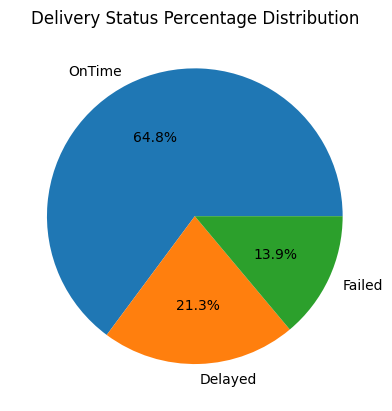

In [10]:
deliveries['delivery_status'].value_counts().plot(
kind='pie',
autopct='%1.1f%%'
)

plt.title('Delivery Status Percentage Distribution')

plt.ylabel('')

plt.show()

In [12]:
base_url = "https://raw.githubusercontent.com/logiha/northstar-database-analytics/main/"

In [15]:
base_url = "https://raw.githubusercontent.com/logiha/northstar-database-analytics/main/"

app_events = pd.read_csv(base_url + "app_events.csv")

In [17]:
customers = pd.read_csv(base_url + "customers.csv")
deliveries = pd.read_csv(base_url + "deliveries.csv")
complaints = pd.read_csv(base_url + "complaints.csv")
vehicles = pd.read_csv(base_url + "vehicles.csv")
incidents = pd.read_csv(base_url + "incidents.csv")
drivers = pd.read_csv(base_url + "drivers.csv")
hubs = pd.read_csv(base_url + "hubs.csv")
app_events = pd.read_csv(base_url + "app_events.csv")

In [18]:
deliveries.head()

,delivery_id,order_id,driver_id,vehicle_id,hub_id,dispatch_time,delivery_completed_at,delivery_status,route_distance_km,manual_route_override_count,proof_of_completion_missing,customer_rating_post_delivery,fuel_or_charge_cost
0,DL00001,O00938,D004,V056,H05,2024-06-18 10:57:00,2024-06-19 09:05:59.904311,Failed,17.26,1,0,3.07,12.05
1,DL00002,O00004,D138,V007,H02,2025-01-11 18:45:00,2025-01-11 17:39:00.000000,OnTime,10.34,1,0,5.00,13.41
2,DL00003,O00639,D006,V049,H02,2025-06-02 20:39:00,2025-06-02 21:45:32.366770,OnTime,7.92,0,0,4.98,8.51
3,DL00004,O00313,D116,V055,H02,2024-03-08 23:31:00,2024-03-09 23:30:08.103702,Delayed,16.42,0,0,4.18,13.62
4,DL00005,O00844,D108,V034,H01,2025-09-21 11:43:00,2025-09-21 15:45:34.131056,OnTime,14.52,1,0,4.18,9.22
